# Parte 2 — Sensibilidad global (ICYA 4715)

Cumple el PDF: método global **Sobol** (S1, ST) con **intervalos de confianza**, justificación de rangos y discusión de parámetros influyentes.

**Sensibilidad Sobol (4 parámetros, rango uniforme):**

| Parámetro | Significado | Rango | Referencia |
|-----------|-------------|-------|------------|
| `n` | Rugosidad Manning | 0.01 – 0.06 | `N_MANN` = 0.035 |
| `S0` | Pendiente fondo | 0.0001 – 0.005 | `S0` = 0.001 |
| `B_W` | Ancho del canal [m] | ±40 % de `sinteticos.B_W` | 50 m |
| `eta_Q` | Factor de escala del aforo aguas arriba [-] | `1 ± k·σ/μ` con σ, μ de `Q_upstream` en calibración (`k=2`) | 1.0 |

**Dos hidrogramas:** aguas arriba = `Q_upstream` del CSV; salida = `Q_downstream` del CSV.
**Y Sobol** = 0.5·(1−NSE_up) + 0.5·(1−NSE_dn) post warm-up. El NSE en salida **no** debe interpretarse como 1 con parámetros de diseño: la columna del CSV y la salida del solver 1D no son la misma definición (ver `GUIA_PROYECTO.txt`).
**OLS:** residuales apilados en ambas estaciones (mismos pesos).

**Tiempo de cómputo:** `USE_LONG_SERIES=True` usa `default_runtime_plan()` (submuestreo + menos muestras Sobol). Para informe final en larga, sube `SOBOL_N` con calma.

**Código:** `src/sensitivity.py`. El notebook solo configura y llama funciones.


In [ ]:
import importlib
import os
import sys
from pathlib import Path

import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import src.model as _model_mod
import src.sensitivity as sab

importlib.reload(_model_mod)
importlib.reload(sab)
from src.model import saint_venant_1d

sinteticos = sab.load_sinteticos_module(ROOT)

L_CANAL = sinteticos.L
NX = 100
WARMUP_SECONDS = 3600.0

PARAM_NAMES = ["n", "S0", "B_W", "eta_Q"]
PARAMS_TRUE_N_S0 = [sinteticos.N_MANN, sinteticos.S0]
BOUNDS_LO_N_S0 = [0.01, 0.0001]
BOUNDS_HI_N_S0 = [0.06, 0.005]

BW_REF = sinteticos.B_W
ETA_K_SIGMA = 2.0  # rango eta_Q = [1 - k*sigma/mu, 1 + k*sigma/mu] del CSV (cal)
BW_REL = 0.4
WEIGHT_UP, WEIGHT_DN = 0.5, 0.5

CAL_FRAC, VAL_FRAC = 0.60, 0.30
SOBOL_METRIC = "nse"
SOBOL_CONF = 0.95

USE_LONG_SERIES = False
INFORME = False

_PLAN = sab.default_runtime_plan(use_long_series=USE_LONG_SERIES, informe=INFORME)
SUBSAMPLE_STRIDE = _PLAN["subsample_stride"]
MAX_NT = _PLAN["max_nt"]
SOBOL_N = _PLAN["sobol_n"]
NBOOT = _PLAN["nboot"]
RUN_COMPLEMENTO = _PLAN["run_ols"]
COMPUTE_SSC = _PLAN["compute_ssc"]
RUN_PROFILING = False
USE_NOISY_CSV = False
RNG_SEED = 42
DH = 1e-4
ST_UMBRAL_REL = 0.10
ALPHA = 0.05

N_JOBS = max(1, (os.cpu_count() or 2) - 1)

CTX = sab.build_sensitivity_context(
    project_root=ROOT,
    saint_venant_fn=saint_venant_1d,
    sinteticos_mod=sinteticos,
    bw_ref=BW_REF,
    l_canal=L_CANAL,
    nx=NX,
    warmup_seconds=WARMUP_SECONDS,
    param_names=PARAM_NAMES,
    params_true_n_s0=PARAMS_TRUE_N_S0,
    bounds_lo_n_s0=BOUNDS_LO_N_S0,
    bounds_hi_n_s0=BOUNDS_HI_N_S0,
    eta_k_sigma=ETA_K_SIGMA,
    bw_rel=BW_REL,
    weight_up=WEIGHT_UP,
    weight_dn=WEIGHT_DN,
    cal_frac=CAL_FRAC,
    val_frac=VAL_FRAC,
    use_long_series=USE_LONG_SERIES,
    use_noisy_csv=USE_NOISY_CSV,
    subsample_stride=SUBSAMPLE_STRIDE,
    max_nt=MAX_NT,
)

N_SOBOL_EVAL = SOBOL_N * (len(PARAM_NAMES) + 2)
print(f"ROOT: {ROOT}")
print(
    f"INFORME: {INFORME} | larga: {USE_LONG_SERIES} | SOBOL_N: {SOBOL_N} | "
    f"stride: {SUBSAMPLE_STRIDE} | max_nt: {MAX_NT} | N_JOBS: {N_JOBS}"
)
sab.print_data_summary(CTX, n_sobol_eval=N_SOBOL_EVAL)
OLS_BUNDLE = None


ROOT: D:\descagas\proyecto-hidrosistemas
INFORME: False | SOBOL_N: 128 | N_JOBS: 3 (de 4 nucleos)
CSV: series_corta_balance.csv  nt=500
warm-up=4  cal=297  val=148
B_W        verdadero=50.00 m  rango Sobol=[30.00, 70.00]
eta_Q      verdadero=1.0000  rango Sobol=[0.0100, 2.3855]  (1 +/- 2.0*sigma/mu, sigma=59.403 mu=85.750 m3/s)
Obs. salida: Q_downstream_m3s del CSV | Y Sobol: w_up=0.50  w_dn=0.50
Evaluaciones Sobol: 768


In [8]:
q_up_true, q_dn_true = CTX.simulator.both(CTX.params_true)
m_true = sab.metrics_table_two_stations(CTX, q_up_true, q_dn_true)
print("Métricas con parámetros de referencia (aguas arriba suele ir bien; salida depende del CSV vs SV):")
m_true


Métricas con parámetros de referencia (aguas arriba suele ir bien; salida depende del CSV vs SV):


,estacion,periodo,NSE,KGE,RMSE_m3s
0,aguas_arriba,calibracion,1.000000,1.000000,0.000000
1,aguas_arriba,validacion,1.000000,1.000000,0.000000
2,aguas_arriba,post_warmup,1.000000,1.000000,0.000000
3,salida,calibracion,-0.572469,-0.355140,80.798999
4,salida,validacion,-2.304725,-0.411835,106.663852
5,salida,post_warmup,-0.670732,-0.339899,85.739149


### Justificación de rangos

- `n`, `S0`: Chow (1959) y piedemonte colombiano (mismo criterio del curso).
- `B_W`: incertidumbre geométrica del canal prismático (±40 % sobre el valor del generador).
- `eta_Q`: rango `1 ± k·σ/μ` con σ y μ de `Q_upstream` en calibración (`k=ETA_K_SIGMA`, por defecto 2). Sin tope fijo del 30 %: lo define la dispersión del CSV.
- Salida: `Q_downstream_m3s` del CSV frente a la simulación en x = L (solver 1D).


## Sobol global (SALib)

**Método:** análisis de varianza (Sobol). S1 = efecto directo; ST = efecto total (con interacciones).

**Muestreo:** Saltelli / `sobol.sample`, distribución **uniforme** en los rangos definidos.

**Paralelismo:** `Parallel(n_jobs=N_JOBS, backend='loky')` — cada worker es un proceso independiente (no hay conflictos de GIL). En Windows, `loky` es más estable que `multiprocessing`. Si el kernel se cuelga, bajar a `N_JOBS=1`.

**Intervalos de confianza:** bootstrap en `sobol.analyze` (`conf_level=0.95`). La figura incluye barras de error en S1 y ST.

Y=0.5*(1-NSE_up)+0.5*(1-NSE_dn) | evaluaciones: 768 | N_JOBS: 3
Corriendo 768 simulaciones en 3 núcleos ...


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done  12 tasks      | elapsed:    3.4s
[Parallel(n_jobs=3)]: Done  66 tasks      | elapsed:   14.7s
[Parallel(n_jobs=3)]: Done 156 tasks      | elapsed:   34.7s
[Parallel(n_jobs=3)]: Done 282 tasks      | elapsed:  1.0min
[Parallel(n_jobs=3)]: Done 444 tasks      | elapsed:  1.6min
[Parallel(n_jobs=3)]: Done 642 tasks      | elapsed:  2.3min
[Parallel(n_jobs=3)]: Done 768 out of 768 | elapsed:  2.7min finished


Listo. Y: min=0.4697  median=1.4901  max=1000000.0000


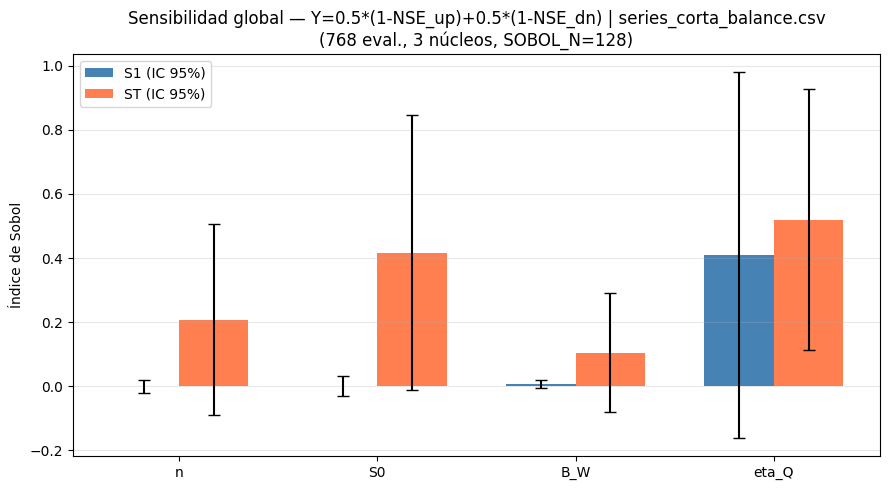

,parametro,S1,S1_conf,ST,ST_conf
0,n,0.0000,0.0210,0.2081,0.2968
1,S0,0.0000,0.0308,0.4163,0.4287
2,B_W,0.0070,0.0126,0.1041,0.1856
3,eta_Q,0.4092,0.5705,0.5203,0.4068


In [9]:
np.random.seed(RNG_SEED)
Y, Si, sobol_df = sab.run_sobol_pipeline(
    CTX,
    sobol_n=SOBOL_N,
    sobol_metric=SOBOL_METRIC,
    sobol_conf=SOBOL_CONF,
    n_jobs=N_JOBS,
    rng_seed=RNG_SEED,
)
display(sobol_df.round(4))


## Conclusiones para calibración

Clasificación según ST (PDF: parámetros influyentes vs. poco sensibles).

In [10]:
sab.write_sobol_conclusions(
    CTX,
    Si=Si,
    Y=Y,
    sobol_metric=SOBOL_METRIC,
    n_jobs=N_JOBS,
    st_umbral_rel=ST_UMBRAL_REL,
)


=== Sensibilidad global (Sobol) ===
Metrica: Y=0.5*(1-NSE_up)+0.5*(1-NSE_dn) | evaluaciones: 768 | N_JOBS: 3
Umbral poco sensible: ST < 10% de max(ST) = 0.0520

  eta_Q: ST=0.5203 +/- 0.4068  S1=0.4092  -> INFLUYENTE
  S0: ST=0.4163 +/- 0.4287  S1=0.0000  -> INFLUYENTE
  n: ST=0.2081 +/- 0.2968  S1=0.0000  -> INFLUYENTE
  B_W: ST=0.1041 +/- 0.1856  S1=0.0070  -> INFLUYENTE

Para calibracion (Parte 3): priorizar parametros INFLUYENTES;
fijar o acotar fuerte los poco sensibles.

Nota eta_Q: ST alto indica que la incertidumbre del aforo aguas arriba
condiciona el ajuste; si ST es bajo, fijar eta_Q=1 en calibracion (Parte 3).
Salida: Q_downstream del CSV frente a simulacion en x = L.


'=== Sensibilidad global (Sobol) ===\nMetrica: Y=0.5*(1-NSE_up)+0.5*(1-NSE_dn) | evaluaciones: 768 | N_JOBS: 3\nUmbral poco sensible: ST < 10% de max(ST) = 0.0520\n\n  eta_Q: ST=0.5203 +/- 0.4068  S1=0.4092  -> INFLUYENTE\n  S0: ST=0.4163 +/- 0.4287  S1=0.0000  -> INFLUYENTE\n  n: ST=0.2081 +/- 0.2968  S1=0.0000  -> INFLUYENTE\n  B_W: ST=0.1041 +/- 0.1856  S1=0.0070  -> INFLUYENTE\n\nPara calibracion (Parte 3): priorizar parametros INFLUYENTES;\nfijar o acotar fuerte los poco sensibles.\n\nNota eta_Q: ST alto indica que la incertidumbre del aforo aguas arriba\ncondiciona el ajuste; si ST es bajo, fijar eta_Q=1 en calibracion (Parte 3).\nSalida: Q_downstream del CSV frente a simulacion en x = L.'

## Complemento OLS (solo con `INFORME=True`)

OLS local + 5 suposiciones del error. No sustituye Sobol; apoya Parte 3.

In [11]:
from IPython.display import display

if not RUN_COMPLEMENTO:
    print("Complemento OLS omitido (INFORME=False).")
    OLS_BUNDLE = None
else:
    OLS_BUNDLE, m_ols_df, params_ols_df = sab.run_ols_bundle(
        CTX,
        nboot=NBOOT,
        n_jobs=N_JOBS,
        alpha_sig=ALPHA,
        dh_ssc=DH,
        compute_ssc=COMPUTE_SSC,
    )
    display(m_ols_df)
    display(params_ols_df)


Complemento OLS omitido (INFORME=False).


## Profiling (opcional, `INFORME=True`)


In [12]:
if RUN_PROFILING and OLS_BUNDLE is not None:
    sab.optional_ydata_profiling(CTX, q_pred=OLS_BUNDLE.q_pred, enabled=True)
elif RUN_PROFILING:
    sab.optional_ydata_profiling(CTX, q_pred=CTX.simulator(CTX.params_true), enabled=True)
else:
    sab.optional_ydata_profiling(CTX, q_pred=CTX.simulator(CTX.params_true), enabled=False)


Profiling omitido. Activar RUN_PROFILING=True para informe final.
